# Machine Learning - Assignment 2

**Student ID:** 2025AC05250  
**Name:** Vasu Gupta

## Dataset and Problem
**Dataset:** UCI Adult Income  
**Problem type:** Binary classification  
**Target:** Predict whether annual income exceeds $50K.


## Dataset Description

The UCI Adult Income dataset contains demographic and employment-related information used to predict whether an individual's annual income exceeds $50K.

After removing rows with missing values, the dataset contains **30,162 instances** and **14 input features**.

## Models Used

The following classification models are evaluated on the UCI Adult Income dataset:

- Logistic Regression
- Decision Tree Classifier
- K-Nearest Neighbor (kNN)
- Gaussian Naive Bayes
- Random Forest


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix)

RANDOM_STATE = 42
os.makedirs('model', exist_ok=True)


In [2]:
# Load the UCI Adult Income dataset
cols = ['age','workclass','fnlwgt','education','education_num','marital_status',
        'occupation','relationship','race','sex','capital_gain','capital_loss',
        'hours_per_week','native_country','income']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
local_dataset = 'adult.csv'

if os.path.exists(local_dataset):
    df = pd.read_csv(local_dataset)
else:
    df = pd.read_csv(url, header=None, names=cols, skipinitialspace=True)
    df.to_csv(local_dataset, index=False)

df = df.replace('?', np.nan).dropna().reset_index(drop=True)

# Binary target: 1 for >50K, 0 otherwise
df['income'] = (df['income'].astype(str).str.strip() == '>50K').astype(int)

print('Dataset shape:', df.shape)
print('Missing values:', int(df.isnull().sum().sum()))
print('Target distribution:\n', df['income'].value_counts())
df.head()


Dataset shape: (30162, 15)
Missing values: 0
Target distribution:
 income
0    22654
1     7508
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [3]:
X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

preprocessor_unscaled = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Numeric columns:', len(numerical_cols))
print('Categorical columns:', len(categorical_cols))


Training rows: 24129
Test rows: 6033
Numeric columns: 6
Categorical columns: 8


## Model Training

All models use the same training and test sets.

Standardization is applied to Logistic Regression and kNN. Tree-based models and Gaussian Naive Bayes are trained without feature scaling. Categorical features are one-hot encoded.


In [11]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=12))
    ]),
    'kNN': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Naive Bayes': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('classifier', GaussianNB())
    ]),
    'Random Forest (Ensemble)': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

model_files = {
    'Logistic Regression': 'logistic_regression.joblib',
    'Decision Tree': 'decision_tree.joblib',
    'kNN': 'knn.joblib',
    'Naive Bayes': 'naive_bayes.joblib',
    'Random Forest (Ensemble)': 'random_forest_ensemble.joblib'
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'ML Model Name': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_test, y_pred)
    })
    predictions[name] = y_pred
    joblib.dump(model, os.path.join('model', model_files[name]))

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)


In [12]:
# Comparison table
comparison_table = results_df.copy()
metric_cols = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
comparison_table[metric_cols] = comparison_table[metric_cols].round(4)
comparison_table.style.hide(axis="index")


ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
Random Forest (Ensemble),0.849200,0.901200,0.728000,0.629200,0.675000,0.580100
Logistic Regression,0.847500,0.902200,0.735400,0.605200,0.664000,0.571100
Decision Tree,0.846200,0.883500,0.731500,0.603900,0.661600,0.567500
kNN,0.827000,0.859500,0.666400,0.610500,0.637200,0.524800
Naive Bayes,0.787300,0.828000,0.661700,0.298300,0.411200,0.339400


## Observations

| ML Model Name | Observation about model performance |
|---|---|
| Logistic Regression | Gives the highest AUC (0.9022) and precision (0.7354). Its F1-score of 0.6640 is slightly lower than Random Forest. |
| Decision Tree | Performs close to Logistic Regression in accuracy and F1-score, but has a lower AUC of 0.8835. |
| kNN | Gives reasonable precision and recall, but its accuracy (0.8270), AUC (0.8595) and F1-score (0.6372) are lower than the other models except Naive Bayes. |
| Naive Bayes | Has the lowest overall performance, particularly in recall (0.2983) and F1-score (0.4112). |
| Random Forest (Ensemble) | Achieves the highest accuracy (0.8492), recall (0.6292), F1-score (0.6750) and MCC (0.5801), giving the best overall performance based on F1-score. |

**Overall Winner:** Random Forest (Ensemble), based on the highest F1-score of **0.6750** on the held-out test set.


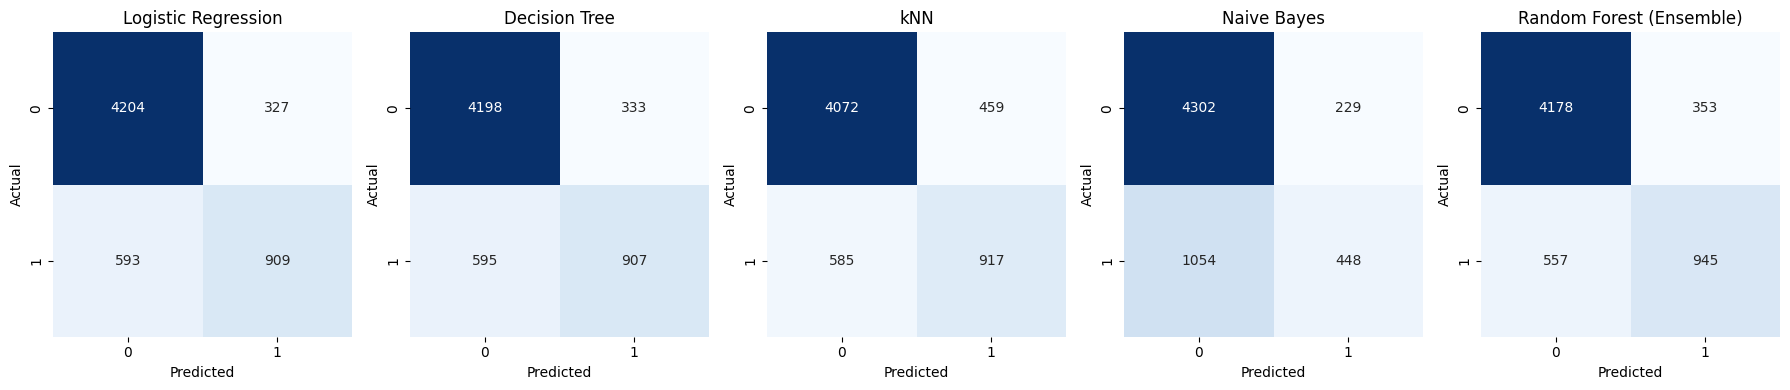

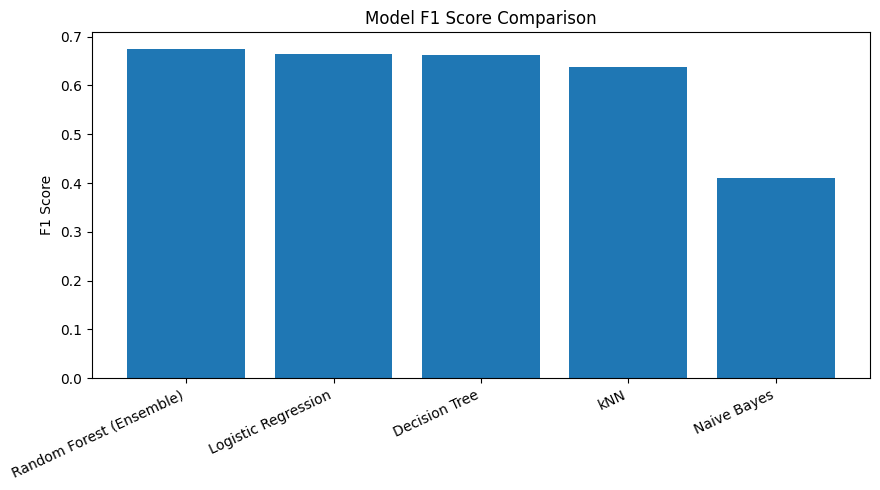

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, len(models), figsize=(18, 4))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# F1 score comparison
plt.figure(figsize=(9, 5))
plt.bar(results_df['ML Model Name'], results_df['F1'])
plt.ylabel('F1 Score')
plt.title('Model F1 Score Comparison')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


In [9]:
# Save test data
test_data = X_test.copy()
test_data['income'] = y_test.values
test_data.to_csv('test_data.csv', index=False)

# Save model metadata
metadata = {
    'target_column': 'income',
    'positive_class': 1,
    'feature_columns': X.columns.tolist(),
    'models': list(models.keys()),
    'model_files': model_files,
    'dataset': 'UCI Adult Income',
    'random_state': RANDOM_STATE
}
with open('model/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

results_df.to_csv('model/comparison_metrics.csv', index=False)

print('Saved test_data.csv')
print('Saved model files:', sorted(os.listdir('model')))


Saved test_data.csv
Saved model files: ['comparison_metrics.csv', 'decision_tree.joblib', 'knn.joblib', 'logistic_regression.joblib', 'metadata.json', 'naive_bayes.joblib', 'random_forest_ensemble.joblib']


## Final Observations

Random Forest gives the best overall result based on F1-score. Logistic Regression has a slightly higher AUC and precision, while Naive Bayes performs weakest, especially for the positive income class.

In [10]:
print(f'Overall Winner: {winner}')


Overall Winner: Random Forest (Ensemble)
